# BAB 10 — CLUSTERING TECHNIQUES

## 10.1 Pengenalan Clustering

Clustering adalah teknik unsupervised learning.

Berbeda dengan classification, clustering tidak membutuhkan label.

Model mencoba menemukan kelompok atau pola secara otomatis.

Contoh penggunaan:

- segmentasi pelanggan
- pengelompokan dokumen
- pengelompokan produk
- analisis pola data

Beberapa algoritma clustering:

- K-Means
- Hierarchical Clustering
- DBSCAN

## 10.2 K-Means

K-Means mengelompokkan data berdasarkan jaraknya terhadap pusat cluster atau centroid.

Proses sederhananya:

1. Menentukan jumlah cluster.
2. Menentukan centroid awal.
3. Setiap data dimasukkan ke centroid terdekat.
4. Centroid dihitung ulang.
5. Proses diulang sampai stabil.

Parameter utama:

n_clusters = jumlah kelompok yang ingin dibuat.

In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(
    n_samples=300,
    centers=3,
    random_state=42
)

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X)

print(labels[:20])

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0]


## 10.3 Visualisasi K-Means

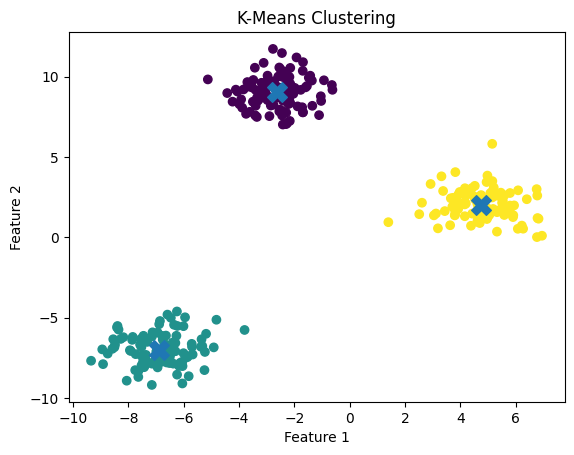

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 10.4 Menentukan Jumlah Cluster

Salah satu cara yang umum digunakan adalah Elbow Method.

Kita menghitung inertia untuk beberapa jumlah cluster.

Inertia menunjukkan seberapa dekat data dengan centroid cluster-nya.

Semakin kecil inertia, semakin dekat data dengan centroid.

Namun kita tidak hanya memilih inertia terkecil. Kita mencari titik ketika penurunan inertia mulai melambat.

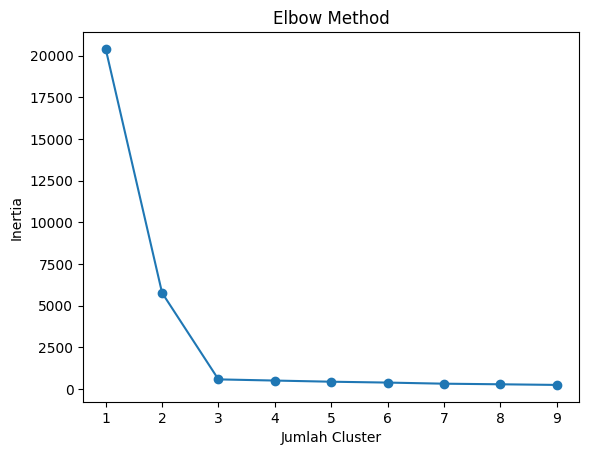

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(1, 10):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)
    inertias.append(model.inertia_)

plt.plot(range(1, 10), inertias, marker="o")

plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

## 10.5 Silhouette Score

Silhouette Score digunakan untuk melihat seberapa baik data berada di dalam cluster.

Nilainya berada antara -1 sampai 1.

Semakin mendekati 1 berarti pemisahan cluster semakin baik.

In [4]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X)

score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.8480303059596955


## 10.6 Hierarchical Clustering

Hierarchical Clustering membuat struktur kelompok secara bertahap.

Pada awalnya setiap data dianggap sebagai satu cluster.

Kemudian cluster yang paling dekat digabungkan sampai terbentuk jumlah cluster yang diinginkan.

In [6]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3
)

labels = model.fit_predict(X)

print(labels[:20])

[0 0 2 1 0 1 2 1 2 2 2 1 2 2 0 2 0 1 2 2]


## 10.7 DBSCAN

DBSCAN melakukan clustering berdasarkan kepadatan data.

Kelebihan DBSCAN:

- tidak harus menentukan jumlah cluster sejak awal.
- dapat menemukan bentuk cluster yang tidak beraturan.
- dapat mendeteksi noise atau outlier.

Parameter penting:

eps = radius pencarian.

min_samples = jumlah minimum titik untuk membentuk area padat.

In [7]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X_moon, _ = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)

model = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = model.fit_predict(X_moon)

print(set(labels))

{np.int64(0), np.int64(1)}


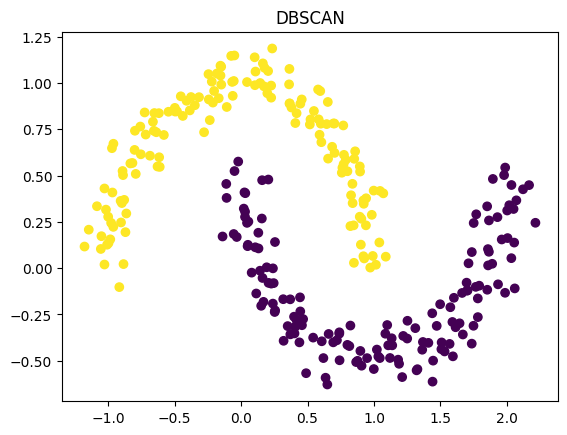

In [8]:
import matplotlib.pyplot as plt

plt.scatter(
    X_moon[:, 0],
    X_moon[:, 1],
    c=labels
)

plt.title("DBSCAN")
plt.show()

## 10.8 Perbandingan Algoritma

K-Means:
- sederhana
- cepat
- membutuhkan jumlah cluster
- cocok untuk cluster yang relatif berbentuk bulat

Hierarchical Clustering:
- membuat struktur hierarki
- dapat digunakan untuk melihat hubungan antar cluster

DBSCAN:
- tidak membutuhkan jumlah cluster
- dapat mendeteksi noise
- cocok untuk cluster dengan bentuk yang tidak beraturan

## 10.9 Kesimpulan Bab 10

Pada bab ini kita mempelajari:

- Unsupervised learning.
- K-Means.
- Elbow Method.
- Silhouette Score.
- Hierarchical Clustering.
- DBSCAN.

Clustering digunakan ketika kita memiliki data tetapi belum memiliki label kelas.